# Part 2: Extended lineage-damage model (v2)

This notebook extends Part 1 by adding damage feedback and repair decline. It also contains two explicit comparisons: a feedback/no-feedback damage trajectory and an optional r/K-style population thought experiment.

## Model rule

$$r_{eff}=\frac{r}{1+qD_t}$$

$$a_{eff}=a(1+fD_t)$$

$$P_t=\max(0,(1-r_{eff})D_t+a_{eff}+\epsilon_t)$$

$$P_t \ge T \Rightarrow \text{cell dies before division}$$

$$D^O_{t+1}=(0.5+s)P_t, \qquad D^N_{t+1}=(0.5-s)P_t$$

D_t is parent damage; a is baseline new damage; r is baseline repair; f is damage feedback; q is repair decline; epsilon_t is noise; T is the death threshold; and s is partitioning asymmetry.

In [1]:
from dataclasses import dataclass
from random import Random
import matplotlib.pyplot as plt

@dataclass
class Cell:
    cell_id: int
    parent_id: int | None
    generation: int
    damage: float
    branch: str
    old_count: int
    alive: bool = True

def update_damage(damage, damage_per_cycle, repair, feedback, repair_decline, noise_sd, rng):
    effective_repair = repair / (1 + repair_decline * damage)
    new_damage = damage_per_cycle * (1 + feedback * damage)
    return max(0.0, (1 - effective_repair) * damage + new_damage + rng.gauss(0, noise_sd))

def simulate_lineage(generations=8, damage_per_cycle=1.0, repair=0.12, asymmetry=0.18,
                     noise_sd=0.12, death_threshold=2.5, feedback=0.15, repair_decline=0.10, seed=7):
    rng = Random(seed)
    cells = [Cell(0, None, 0, 0.0, '', 0)]
    current, next_id = [cells[0]], 1
    for generation in range(1, generations + 1):
        next_generation = []
        for parent in current:
            before_division = update_damage(parent.damage, damage_per_cycle, repair, feedback, repair_decline, noise_sd, rng)
            if before_division >= death_threshold:
                parent.damage, parent.alive = before_division, False
                continue
            old = Cell(next_id, parent.cell_id, generation, (0.5 + asymmetry) * before_division, parent.branch + 'O', parent.old_count + 1)
            new = Cell(next_id + 1, parent.cell_id, generation, (0.5 - asymmetry) * before_division, parent.branch + 'N', parent.old_count)
            cells.extend((old, new))
            next_generation.extend((old, new))
            next_id += 2
        current = next_generation
        if not current:
            break
    return cells

def terminal_survivors(cells, generations):
    parent_ids = {cell.parent_id for cell in cells if cell.parent_id is not None}
    return [cell for cell in cells if cell.cell_id not in parent_ids and cell.alive and cell.generation == generations]

def plot_lineage_dashboard(cells, generations):
    children = {cell.cell_id: [] for cell in cells}
    for cell in cells:
        if cell.parent_id is not None:
            children[cell.parent_id].append(cell.cell_id)
    leaves = [cell for cell in cells if not children[cell.cell_id]]
    positions = {cell.cell_id: (i, cell.generation) for i, cell in enumerate(leaves)}
    for generation in range(generations - 1, -1, -1):
        for cell in [c for c in cells if c.generation == generation and children[c.cell_id]]:
            xs = [positions[child_id][0] for child_id in children[cell.cell_id]]
            positions[cell.cell_id] = (sum(xs) / len(xs), cell.generation)

    survivors = terminal_survivors(cells, generations)
    deaths = [cell for cell in cells if not cell.alive]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for cell in cells:
        if cell.parent_id is not None:
            x0, y0 = positions[cell.parent_id]
            x1, y1 = positions[cell.cell_id]
            color = '#b64e3b' if cell.branch.endswith('O') else '#4d7496'
            axes[0].plot([x0, x1], [y0, y1], color=color, alpha=.38, lw=.75)
    nodes = axes[0].scatter(*zip(*[positions[cell.cell_id] for cell in cells]), c=[cell.damage for cell in cells], cmap='plasma', s=22, zorder=3)
    for cell in deaths:
        axes[0].plot(*positions[cell.cell_id], marker='x', color='black', ms=7, mew=1.5, zorder=4)
    axes[0].invert_yaxis()
    axes[0].set(title='Lineage tree', xlabel='terminal order', ylabel='generation')
    fig.colorbar(nodes, ax=axes[0], label='damage', pad=.01)

    if survivors:
        axes[1].hist([cell.damage for cell in survivors], bins=12, color='#735b9a', edgecolor='white')
    else:
        axes[1].text(.5, .5, 'No terminal survivors', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set(title='Terminal damage distribution', xlabel='damage', ylabel='terminal cells')

    if len(survivors) >= 2:
        xs = [cell.old_count for cell in survivors]
        ys = [cell.damage for cell in survivors]
        axes[2].scatter(xs, ys, color='#243b53', alpha=.72)
        mean_x, mean_y = sum(xs) / len(xs), sum(ys) / len(ys)
        numerator = sum((x - mean_x) * (y - mean_y) for x, y in zip(xs, ys))
        x_spread = sum((x - mean_x) ** 2 for x in xs)
        y_spread = sum((y - mean_y) ** 2 for y in ys)
        correlation = numerator / max((x_spread * y_spread) ** .5, 1e-12)
        if x_spread > 0:
            slope, intercept = numerator / x_spread, mean_y - numerator / x_spread * mean_x
            x_line = [min(xs), max(xs)]
            axes[2].plot(x_line, [slope * x + intercept for x in x_line], color='#d95f02', lw=2)
        title = f'Inheritance signal (r={correlation:.2f})'
    else:
        axes[2].text(.5, .5, 'Too few terminal survivors', ha='center', va='center', transform=axes[2].transAxes)
        title = 'Inheritance signal'
    axes[2].set(title=title, xlabel='number of O decisions', ylabel='terminal damage')
    plt.tight_layout()
    return None

Terminal survivors: 124
Cells that died before dividing: 23
Mean terminal damage: 0.93


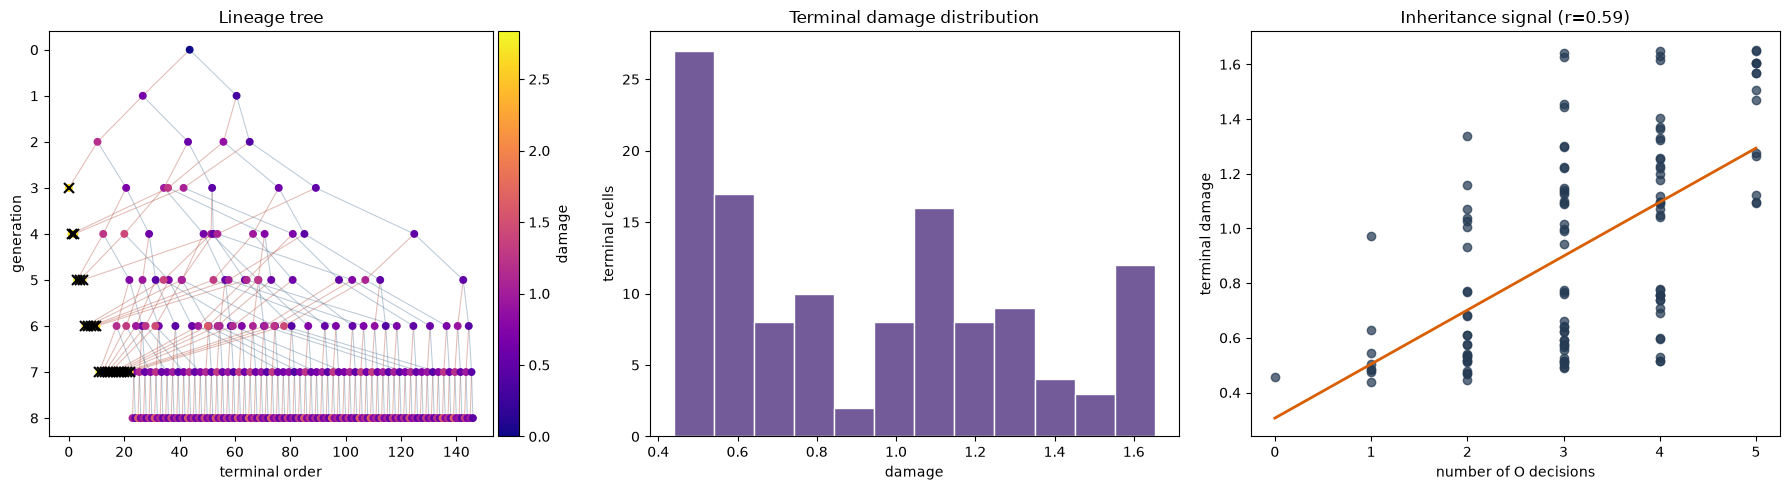

In [2]:
# First set feedback=repair_decline=0 to recover the Part 1 rule.
params = dict(generations=8, damage_per_cycle=1.0, repair=0.12, asymmetry=0.18,
              noise_sd=0.12, death_threshold=2.5, feedback=0.15, repair_decline=0.10, seed=7)
cells = simulate_lineage(**params)
survivors = terminal_survivors(cells, params['generations'])
deaths = [cell for cell in cells if not cell.alive]
print(f'Terminal survivors: {len(survivors)}')
print(f'Cells that died before dividing: {len(deaths)}')
print(f'Mean terminal damage: {sum(c.damage for c in survivors) / len(survivors):.2f}' if survivors else 'No terminal survivors')
plot_lineage_dashboard(cells, params['generations'])

## Feedback versus no feedback

First compare the full branching model after it has run: terminal damage and the association between ancestry and terminal state. Both simulations use the same random seed; only feedback and repair decline differ.

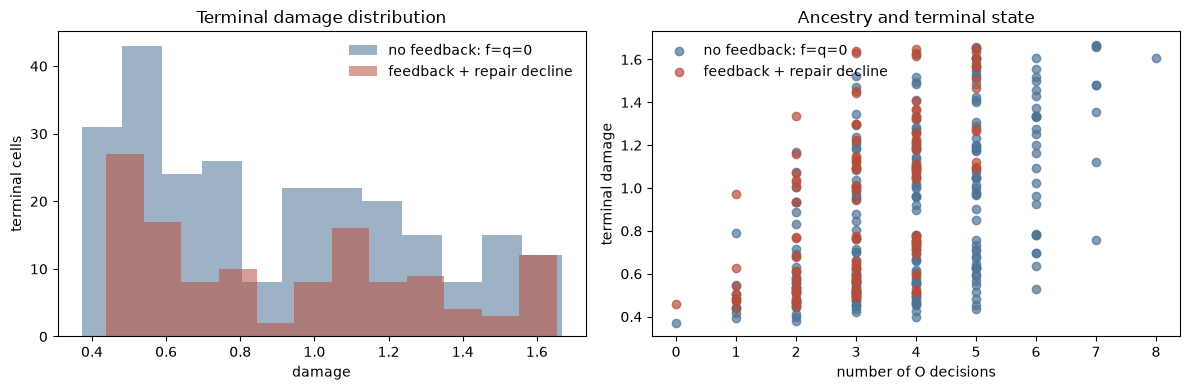

In [3]:
minimal = simulate_lineage(**{**params, 'feedback': 0.0, 'repair_decline': 0.0})
extended = simulate_lineage(**params)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cells_for_plot, label, color in [(minimal, 'no feedback: f=q=0', '#4d7496'), (extended, 'feedback + repair decline', '#b64e3b')]:
    selected = terminal_survivors(cells_for_plot, params['generations'])
    axes[0].hist([cell.damage for cell in selected], bins=12, alpha=.55, label=label, color=color)
    axes[1].scatter([cell.old_count for cell in selected], [cell.damage for cell in selected], alpha=.7, label=label, color=color)
axes[0].set(title='Terminal damage distribution', xlabel='damage', ylabel='terminal cells')
axes[1].set(title='Ancestry and terminal state', xlabel='number of O decisions', ylabel='terminal damage')
for axis in axes:
    axis.legend(frameon=False)
plt.tight_layout()

Next, isolate the within-cell update rule. This trajectory follows one representative cell for several cycles, without partitioning or threshold death. The illustrative settings below are deliberately strong enough to make the nonlinear effect of feedback visible; they are not a fitted biological parameter set.

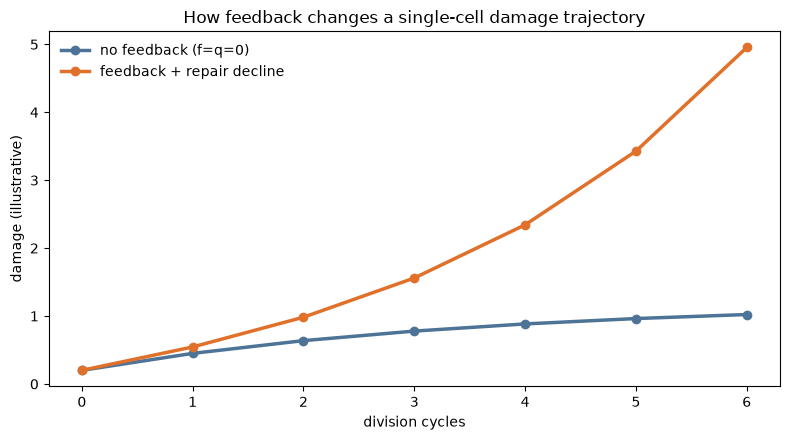

In [4]:
def damage_trajectory(cycles, damage0, damage_per_cycle, repair, feedback, repair_decline, seed=7):
    rng, damage, trajectory = Random(seed), damage0, [damage0]
    for _ in range(cycles):
        damage = update_damage(damage, damage_per_cycle, repair, feedback, repair_decline, 0.0, rng)
        trajectory.append(damage)
    return trajectory

cycles = 6
no_feedback = damage_trajectory(cycles, damage0=.2, damage_per_cycle=.30, repair=.25, feedback=0.0, repair_decline=0.0)
feedback_decline = damage_trajectory(cycles, damage0=.2, damage_per_cycle=.30, repair=.25, feedback=1.50, repair_decline=.50)

plt.figure(figsize=(8, 4.5))
plt.plot(range(cycles + 1), no_feedback, 'o-', color='#4d7496', lw=2.5, label='no feedback (f=q=0)')
plt.plot(range(cycles + 1), feedback_decline, 'o-', color='#e0702a', lw=2.5, label='feedback + repair decline')
plt.xlabel('division cycles')
plt.ylabel('damage (illustrative)')
plt.title('How feedback changes a single-cell damage trajectory')
plt.legend(frameon=False)
plt.tight_layout()

## Optional notebook-only extension: r/K-style population thought experiment

The labels below are deliberately stylised. They are a way to explore a growth--maintenance trade-off under density limitation, not a claim that real cells fall into two fixed ecological categories. Living population and cumulative deaths are plotted separately because they answer different questions and have very different scales.

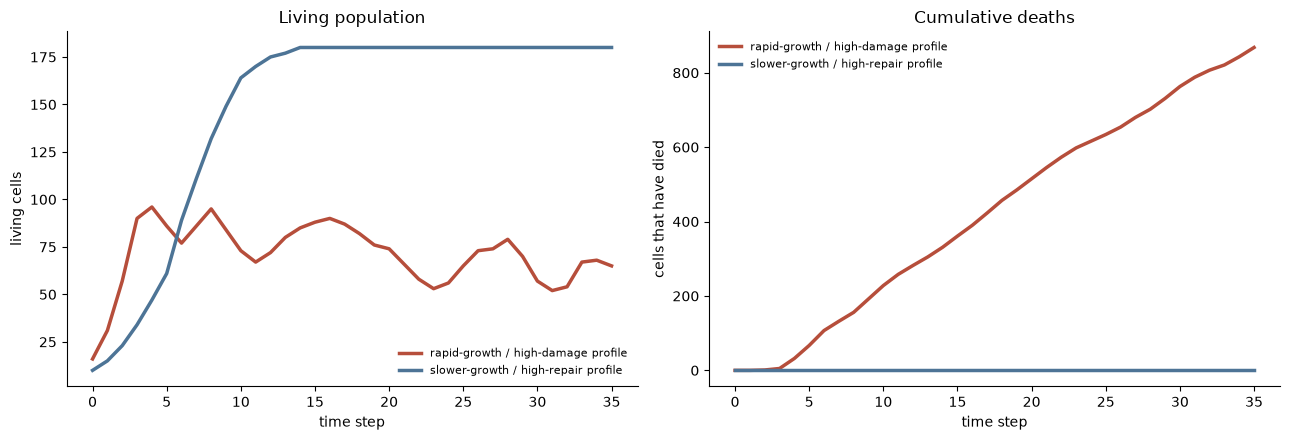

In [5]:
def simulate_population(steps, initial_cells, carrying_capacity, division_probability,
                        damage_per_cycle, repair, asymmetry, noise_sd, death_threshold,
                        feedback, repair_decline, seed):
    rng, population, deaths = Random(seed), [0.0] * initial_cells, 0
    history = []
    for time in range(steps):
        density_factor = max(0.0, 1 - len(population) / carrying_capacity)
        next_population = []
        for damage in population:
            before = update_damage(damage, damage_per_cycle, repair, feedback, repair_decline, noise_sd, rng)
            if before >= death_threshold:
                deaths += 1
            elif rng.random() < division_probability * density_factor:
                next_population.extend(((0.5 + asymmetry) * before, (0.5 - asymmetry) * before))
            else:
                next_population.append(before)
        population = next_population
        history.append((time, len(population), deaths))
    return history

common = dict(steps=36, initial_cells=8, carrying_capacity=180, asymmetry=.18, noise_sd=.08, death_threshold=2.1)
rapid_growth = simulate_population(**common, division_probability=.95, damage_per_cycle=.78, repair=.08, feedback=.22, repair_decline=.30, seed=19)
high_repair = simulate_population(**common, division_probability=.55, damage_per_cycle=.32, repair=.35, feedback=.05, repair_decline=.05, seed=37)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
profiles = [(rapid_growth, 'rapid-growth / high-damage profile', '#b64e3b'), (high_repair, 'slower-growth / high-repair profile', '#4d7496')]
for history, label, color in profiles:
    time, alive, deaths = zip(*history)
    axes[0].plot(time, alive, color=color, lw=2.5, label=label)
    axes[1].plot(time, deaths, color=color, lw=2.5, label=label)
axes[0].set(title='Living population', xlabel='time step', ylabel='living cells')
axes[1].set(title='Cumulative deaths', xlabel='time step', ylabel='cells that have died')
for axis in axes:
    axis.legend(frameon=False, fontsize=8)
    axis.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

For the r/K-style exercise, change one profile parameter at a time. Ask separately: what controls population size at a given time, and what controls the accumulated burden of death? Then name the biological measurements needed before using this toy result to reason about a real system.